In [3]:
import pandas as pd
import numpy as np

# 1. Mevcut veri setini yükle
df = pd.read_csv('personel_ai_veri_seti.csv')

# 2. Daha doğal dağılım için rastgele doldurma stratejisi
hedefler = df['Hedef'].unique()
programlar = df['Program_Etiketi'].unique()

ek_veriler = []

for h in hedefler:
    for p in programlar:
        # Sabit 50 yerine, her hücre için 30 ile 80 arasında rastgele bir hedef sayı belirle
        hedef_doluluk = np.random.randint(30, 81) 
        mevcut_sayi = len(df[(df['Hedef'] == h) & (df['Program_Etiketi'] == p)])
        
        # Eğer mevcut sayı rastgele belirlediğimiz hedefin altındaysa, aradaki fark kadar üret
        if mevcut_sayi < hedef_doluluk:
            fark = hedef_doluluk - mevcut_sayi
            for _ in range(fark):
                yeni_kayit = {
                    'Yas': np.random.randint(18, 65),
                    'Cinsiyet': np.random.choice([0, 1]),
                    'Boy': np.random.randint(150, 200),
                    'Kilo': np.random.randint(50, 120),
                    'Aktivite_Seviyesi': np.random.choice([1.2, 1.375, 1.55, 1.725, 1.9]),
                    'Sakatlik_Bolgesi': np.random.choice(['Yok', 'Diz', 'Omuz', 'Bel', 'Ayak Bileği']),
                    'Sakatlik_Siddeti': np.random.uniform(0, 5.0),
                    'Spor_Gecmisi_Yil': np.random.randint(0, 15),
                    'Hedef': h,
                    'Ekipman': np.random.choice(['Full Gym', 'Dumbbell Only', 'Bodyweight']),
                    'Ogun_Tercihi': np.random.randint(2, 6),
                    'Program_Etiketi': p
                }
                # VKI ve Sakatlık Şiddeti arasında hafif bir mantıksal gürültü ekle
                yeni_kayit['VKI'] = round(yeni_kayit['Kilo'] / ((yeni_kayit['Boy'] / 100) ** 2), 2)
                ek_veriler.append(yeni_kayit)

# 3. Verileri birleştir ve karıştır
df_ek = pd.DataFrame(ek_veriler)
df_final = pd.concat([df, df_ek], ignore_index=True)
df_final = df_final.sample(frac=1).reset_index(drop=True) 

# 4. Kaydet
df_final.to_csv('personel_ai_veri_seti.csv', index=False)

print(f"Toplam Veri Sayısı: {len(df_final)}")
print("\n--- DOĞAL DAĞILIMLI ÇAPRAZ TABLO ---")
print(pd.crosstab(df_final['Hedef'], df_final['Program_Etiketi']))

Toplam Veri Sayısı: 2335

--- DOĞAL DAĞILIMLI ÇAPRAZ TABLO ---
Program_Etiketi   KILO_ALMA  PPL_SPLIT  REHABILITASYON  YAG_YAKIMI
Hedef                                                             
Güç ve Kondisyon         71        857              80          72
Kas Kazanımı            264         77              56          65
Kilo Verme               50         59              60         263
Sakatlık Sonrası         72         50             189          50


Rapor Hazırlanıyor... (Toplam Kayıt: 2335)


C:\Users\Ghost\AppData\Local\Temp\ipykernel_5080\1720441326.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, y='Program_Etiketi', order=order, palette='viridis')


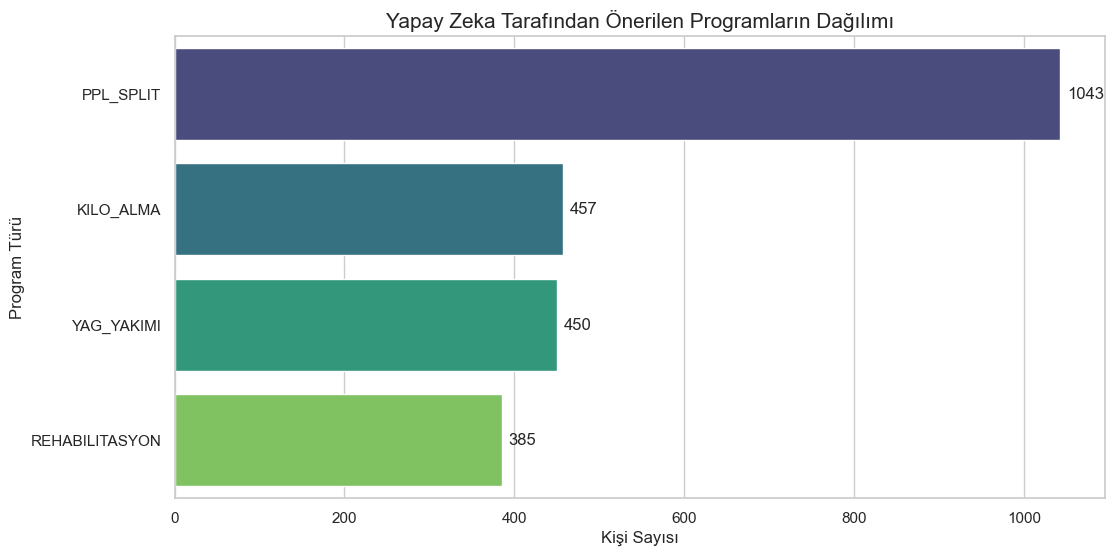

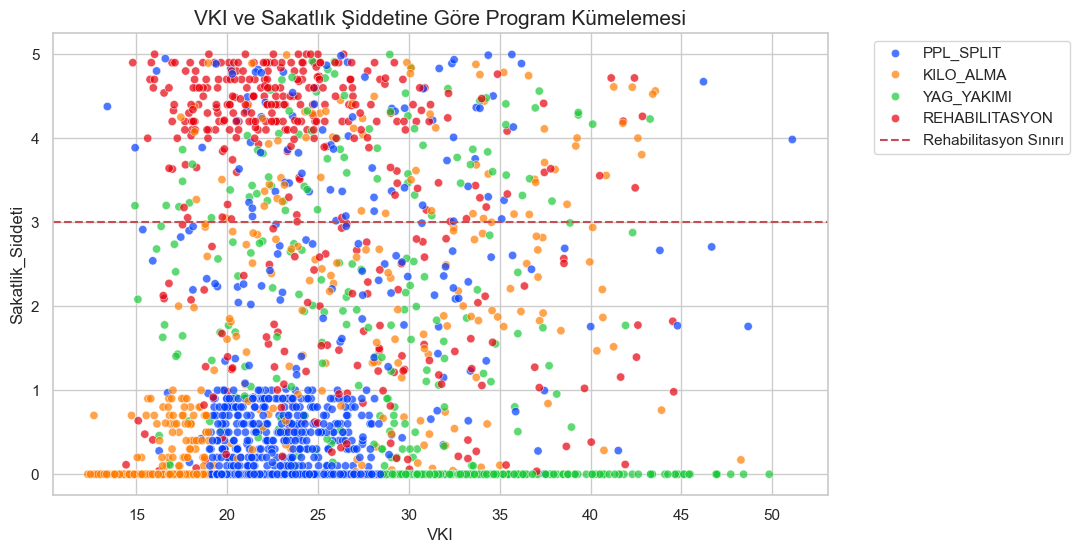

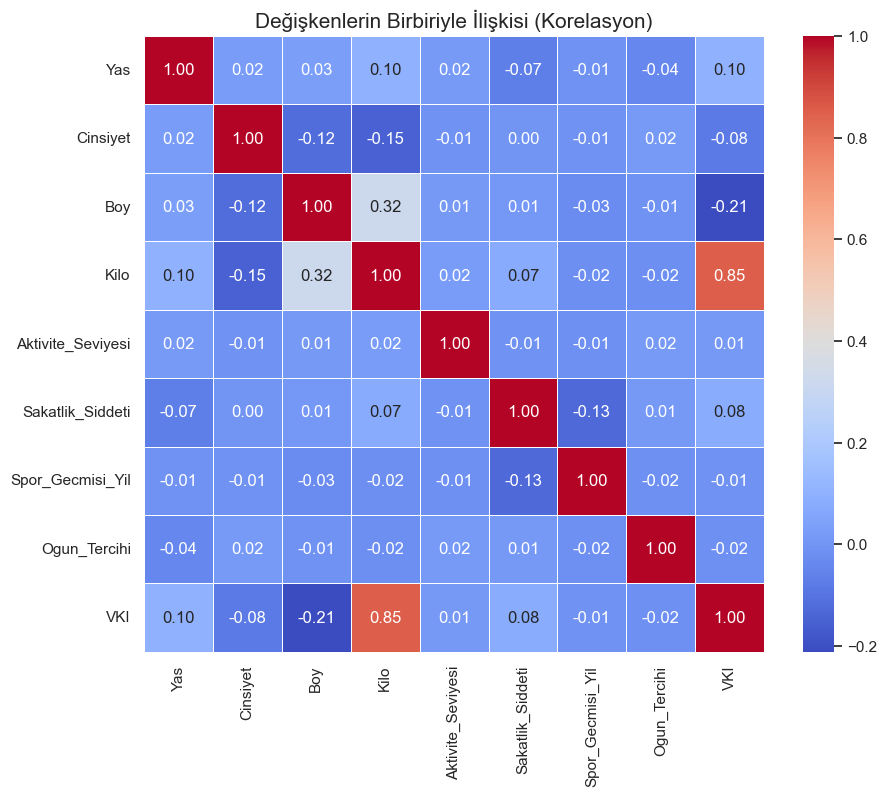


HEDEF VE PROGRAM EŞLEŞME TABLOSU
Program_Etiketi   KILO_ALMA  PPL_SPLIT  REHABILITASYON  YAG_YAKIMI
Hedef                                                             
Güç ve Kondisyon         71        857              80          72
Kas Kazanımı            264         77              56          65
Kilo Verme               50         59              60         263
Sakatlık Sonrası         72         50             189          50


In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Güncel Veriyi Yükle
df = pd.read_csv('personel_ai_veri_seti.csv')

# Grafiklerin genel stilini ayarla
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

print(f"Rapor Hazırlanıyor... (Toplam Kayıt: {len(df)})")

# --- GRAFİK 1: Program Etiketlerinin Dağılımı ---
plt.figure(figsize=(12, 6))
order = df['Program_Etiketi'].value_counts().index
ax = sns.countplot(data=df, y='Program_Etiketi', order=order, palette='viridis')
plt.title('Yapay Zeka Tarafından Önerilen Programların Dağılımı', fontsize=15)
plt.xlabel('Kişi Sayısı')
plt.ylabel('Program Türü')

# Çubukların üzerine sayıları yaz
for i in ax.containers:
    ax.bar_label(i, padding=5)
plt.show()

# --- GRAFİK 2: VKI ve Sakatlık Şiddeti İlişkisi ---
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='VKI', y='Sakatlik_Siddeti', hue='Program_Etiketi', palette='bright', alpha=0.7)
plt.title('VKI ve Sakatlık Şiddetine Göre Program Kümelemesi', fontsize=15)
plt.axhline(y=3.0, color='r', linestyle='--', label='Rehabilitasyon Sınırı')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# --- GRAFİK 3: Korelasyon Isı Haritası ---
plt.figure(figsize=(10, 8))
# Sadece sayısal sütunları seç
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Değişkenlerin Birbiriyle İlişkisi (Korelasyon)', fontsize=15)
plt.show()

# --- ÖZET TABLO ---
print("\n" + "="*40)
print("HEDEF VE PROGRAM EŞLEŞME TABLOSU")
print("="*40)
print(pd.crosstab(df['Hedef'], df['Program_Etiketi']))

In [15]:
import pandas as pd
import numpy as np

# 1. Veriyi Yükle
df = pd.read_csv('personel_ai_veri_seti.csv')

# --- BÖLÜM 1: GENEL VERİ ANALİZ RAPORU ---
print("="*60)
print("             GENEL VERİ ANALİZ RAPORU             ")
print("="*60)
print(f"Toplam Kayıt Sayısı      : {len(df)}")
print(f"Öznitelik (Sütun) Sayısı : {len(df.columns)}")
print("-" * 60)
print("SÜTUN LİSTESİ VE VERİ TİPLERİ:")
print(df.dtypes)
print("-" * 60)
print("EKSİK VERİ KONTROLÜ (Missing Values):")
print(df.isnull().sum())

# --- BÖLÜM 2: TEMEL İSTATİSTİKLER TABLOSU ---
print("\n" + "="*60)
print("          SAYISAL VERİLERİN TEMEL İSTATİSTİKLERİ      ")
print("="*60)
# describe() fonksiyonu; count, mean, std, min, %25, %50, %75, max değerlerini verir.
print(df.describe().round(2).transpose())

# --- BÖLÜM 3: KATEGORİK DAĞILIM TABLOLARI ---
print("\n" + "="*60)
print("          KATEGORİK DEĞİŞKENLERİN DAĞILIMI            ")
print("="*60)

print("\n[PROGRAM ETİKETİ DAĞILIMI]")
print(df['Program_Etiketi'].value_counts())

print("\n[HEDEF DAĞILIMI]")
print(df['Hedef'].value_counts())

# --- BÖLÜM 4: KORELASYON MATRİSİ (METİN FORMATI) ---
print("\n" + "="*60)
print("             KORELASYON MATRİSİ (SAYISAL)             ")
print("="*60)
print(df.select_dtypes(include=[np.number]).corr().round(3))

# --- BÖLÜM 5: HEDEF VE PROGRAM ÇAPRAZ TABLOSU ---
print("\n" + "="*60)
print("       HEDEF VE PROGRAM ETİKETİ ÇAPRAZ TABLOSU        ")
print("="*60)
print(pd.crosstab(df['Hedef'], df['Program_Etiketi']))
print("="*60)

             GENEL VERİ ANALİZ RAPORU             
Toplam Kayıt Sayısı      : 2335
Öznitelik (Sütun) Sayısı : 13
------------------------------------------------------------
SÜTUN LİSTESİ VE VERİ TİPLERİ:
Yas                    int64
Cinsiyet               int64
Boy                  float64
Kilo                 float64
Aktivite_Seviyesi    float64
Sakatlik_Bolgesi      object
Sakatlik_Siddeti     float64
Spor_Gecmisi_Yil       int64
Hedef                 object
Ekipman               object
Ogun_Tercihi           int64
VKI                  float64
Program_Etiketi       object
dtype: object
------------------------------------------------------------
EKSİK VERİ KONTROLÜ (Missing Values):
Yas                  0
Cinsiyet             0
Boy                  0
Kilo                 0
Aktivite_Seviyesi    0
Sakatlik_Bolgesi     0
Sakatlik_Siddeti     0
Spor_Gecmisi_Yil     0
Hedef                0
Ekipman              0
Ogun_Tercihi         0
VKI                  0
Program_Etiketi      0
dtype: